正在读取全市场数据，请稍候...
正在计算 MACD 指标与金叉/死叉信号...
开始按日执行【纯净版MACD】策略模拟...
已回测 0/3935 个交易日...
已回测 500/3935 个交易日...
已回测 1000/3935 个交易日...
已回测 1500/3935 个交易日...
已回测 2000/3935 个交易日...
已回测 2500/3935 个交易日...
已回测 3000/3935 个交易日...
已回测 3500/3935 个交易日...

✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\纯净版MACD策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 纯净版MACD最终总资产: 2,935.40 元
📈 策略总收益率: -94.13%


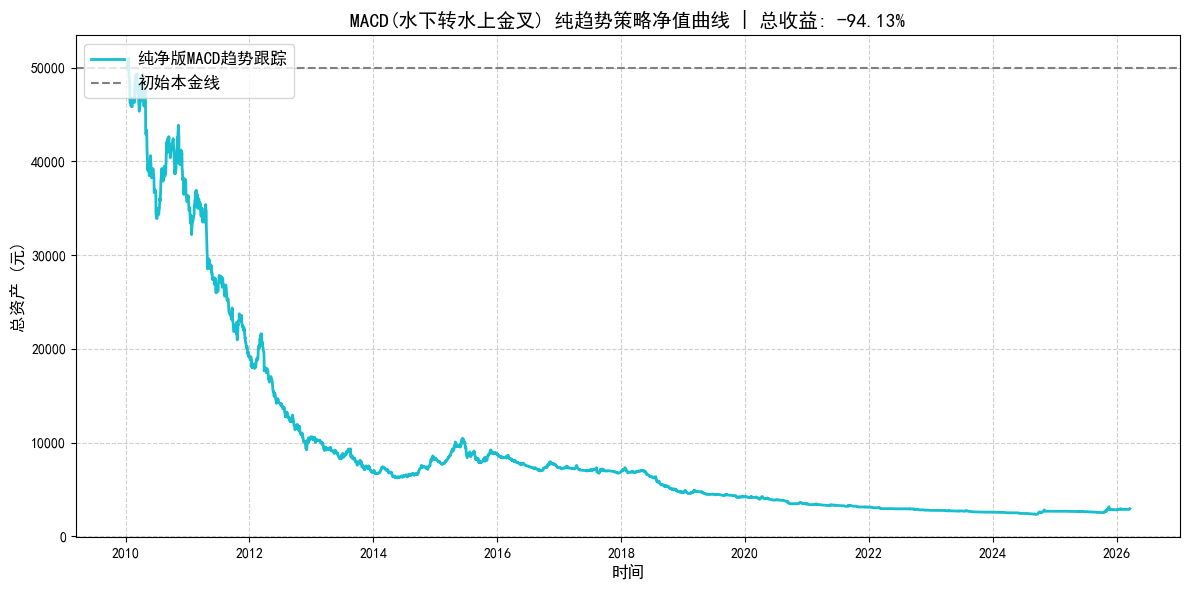

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\纯净版MACD策略明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤主板数据
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# ==========================================
# 第二步：向量化预计算 MACD 及买卖信号
# ==========================================
print("正在计算 MACD 指标与金叉/死叉信号...")
df.sort_values(by=['code', 'date'], inplace=True)

# 1. 计算 MACD (参数 12, 26, 9)
df['EMA12'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
df['EMA26'] = df.groupby('code')['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['DIF'] = df['EMA12'] - df['EMA26']
df['DEA'] = df.groupby('code')['DIF'].transform(lambda x: x.ewm(span=9, adjust=False).mean())

# 2. 判断金叉与死叉
df['prev_DIF'] = df.groupby('code')['DIF'].shift(1)
df['prev_DEA'] = df.groupby('code')['DEA'].shift(1)

df['GC'] = (df['DIF'] > df['DEA']) & (df['prev_DIF'] <= df['prev_DEA'])
df['DC'] = (df['DIF'] < df['DEA']) & (df['prev_DIF'] >= df['prev_DEA'])

# 3. 记录上一次金叉时的位置
df['GC_DIF_Value'] = np.where(df['GC'], df['DIF'], np.nan)
df['prev_GC_DIF'] = df.groupby('code')['GC_DIF_Value'].transform(lambda x: x.ffill().shift(1))

# 4. 生成核心买卖信号 (纯净版)
# 买入：今天金叉 & 水上(DIF>0) & 上次水下(prev_GC_DIF<0)
df['Buy_Signal'] = df['GC'] & (df['DIF'] > 0) & (df['prev_GC_DIF'] < 0)
# 卖出：只要死叉就卖
df['Sell_Signal'] = df['DC']

# ==========================================
# 第三步：定义简化的账户类
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}  # {'code': {'volume': 股数, 'price': 成本价}}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

account = Account(INITIAL_CASH)

# ==========================================
# 第四步：按日执行交易主引擎
# ==========================================
print("开始按日执行【纯净版MACD】策略模拟...")

grouped = df.groupby('date')
dates = sorted(list(grouped.groups.keys()))
total_days = len(dates)

for i, date in enumerate(dates):
    daily_data = grouped.get_group(date).set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    if i % 500 == 0:
        print(f"已回测 {i}/{total_days} 个交易日...")

    # ---------------- 1. 卖出逻辑 (无条件死叉清仓) ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code in daily_data.index and daily_data.loc[code, 'Sell_Signal']:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                cost_price = account.positions[code]['price']

                fee, amount = calculate_fees('sell', sell_price, sell_vol)
                account.cash += (amount - fee)
                del account.positions[code]

                # 判断是止盈还是止损，方便记录日志
                pnl_status = "止盈" if sell_price > cost_price else "止损"

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': f'卖出({pnl_status})',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                    '备注': '触发死叉，无条件清仓'
                })

    # ---------------- 2. 买入逻辑 (水下转水上金叉) ----------------
    empty_slots = TARGET_STOCK_NUM - len(account.positions)

    if empty_slots > 0:
        # 获取今天满足买入信号且可以交易的股票
        buy_candidates = daily_data[
            (daily_data['Buy_Signal'] == True) &
            (daily_data['tradestatus'] == 1) &
            (daily_data['isST'] == 0) &
            (daily_data['pctChg'] < 9.8) &
            (~daily_data.index.isin(account.positions.keys())) # 不重复买入
        ].copy()

        if len(buy_candidates) > 0:
            # 如果触发信号的股票数量超过空位，按DIF强度(金叉力度)排序挑选
            buy_candidates = buy_candidates.sort_values(by='DIF', ascending=False).head(empty_slots)
            target_codes = buy_candidates.index.tolist()

            target_cash_per_stock = account.cash / empty_slots

            for code in target_codes:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)

                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                            '备注': '水下转水上金叉'
                        })

# ==========================================
# 第五步：输出结果与可视化
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
print(f"💰 纯净版MACD最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], color='#17becf', linewidth=2, label='纯净版MACD趋势跟踪')
plt.title(f'MACD(水下转水上金叉) 纯趋势策略净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
plt.xlabel('时间', fontsize=12)
plt.ylabel('总资产 (元)', fontsize=12)
plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金线')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()